# Section 2  : 1D Signal Visualization

In [169]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.preprocessing import MinMaxScaler

# 2.1 
Utilize the ECG5000 dataset available on the Physionet Repository

(https://www.timeseriesclassification.com/description.php?Dataset=ECG5000 Date: Febru-
ary 2, 2023) for visualizing and interpreting the time-domain and frequency-
domain components of electrocardiogram signals.

## Answers
We loaded the training dataset from a CSV file containing 141 columns (140 time-series points + 1 class label). The dataset includes 5 distinct heartbeat classes extracted from the accompanying metadata file.

In [ ]:
# Load ECG5000 Dataset (Adjust the path if needed)
file_path = "./Dataset/ECG5000_TRAIN.txt"
df = pd.read_csv(file_path, delimiter=r"\s+", header=None, engine="python")


# Assign class labels (Ensure class column is correctly extracted)
file_path_ts = "./Dataset/ECG5000_TRAIN.ts"
classes = []
with open(file_path_ts, "r") as file:
    for i, line in enumerate(file):
        if i >= 9:  # Assuming first few lines are metadata
            classes.append(int(line.strip().split(':')[1]))
df["Class"] = classes
print(df.head())



     0         1         2         3         4         5         6         7  \
0  1.0 -0.112522 -2.827204 -3.773897 -4.349751 -4.376041 -3.474986 -2.181408   
1  1.0 -1.100878 -3.996840 -4.285843 -4.506579 -4.022377 -3.234368 -1.566126   
2  1.0 -0.567088 -2.593450 -3.874230 -4.584095 -4.187449 -3.151462 -1.742940   
3  1.0  0.490473 -1.914407 -3.616364 -4.318823 -4.268016 -3.881110 -2.993280   
4  1.0  0.800232 -0.874252 -2.384761 -3.973292 -4.338224 -3.802422 -2.534510   

          8         9  ...       132       133       134       135       136  \
0 -1.818286 -1.250522  ...  0.792168  0.933541  0.796958  0.578621  0.257740   
1 -0.992258 -0.754680  ...  0.538356  0.656881  0.787490  0.724046  0.555784   
2 -1.490659 -1.183580  ...  0.886073  0.531452  0.311377 -0.021919 -0.713683   
3 -1.671131 -1.333884  ...  0.350816  0.499111  0.600345  0.842069  0.952074   
4 -1.783423 -1.594450  ...  1.148884  0.958434  1.059025  1.371682  1.277392   

        137       138       139       

In [171]:
print("Number of classes:", df["Class"].nunique())
unique_classes = df["Class"].unique()
print(df["Class"].value_counts())

Number of classes: 5
Class
1    292
2    177
4     19
3     10
5      2
Name: count, dtype: int64


# 2.2
Plot the ECG signal with all the heartbeats concatenated, and sub-
sets of heartbeats (clusters) – one per class, as depicted in Figure 1.

When necessary, apply centering, or amplitude/length normalization
for better visualization.

## Answers
We first normalize all signal values to the range [-1, 1] using MinMax scaling to ensure consistent amplitude ranges across recordings. This step preprocessing ensures optimal conditions for subsequent frequency analysis and classification.

In [172]:
targets = df["Class"]
df = df.drop(columns=["Class"])
print("Minimum value",np.min(df),"\nMaximum value",np.max(df))

# Normalize each signal amplitude to [-1, 1] using MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df = pd.DataFrame(scaler.fit_transform(df.T).T, columns=df.columns)
# Combine with class labels
df = df.copy()
df["Class"] = targets.values
df["Class"] = df["Class"].astype("int")


Minimum value -5.7976446 
Maximum value 5.0


We first visualize all time-series signals concatenated together (Amplitude vs Time) to show the complete dataset distribution. Then we generate two types of class-specific visualizations: (1) A combined plot displaying all classes in one figure for direct comparison (as in Figure 1 of the assignment), followed by (2) individual plots for each class to enable detailed examination of signal characteristics.

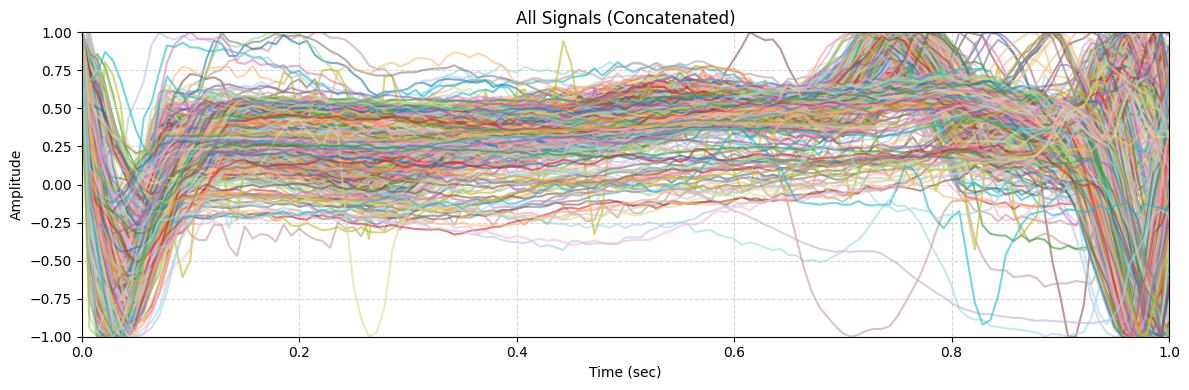

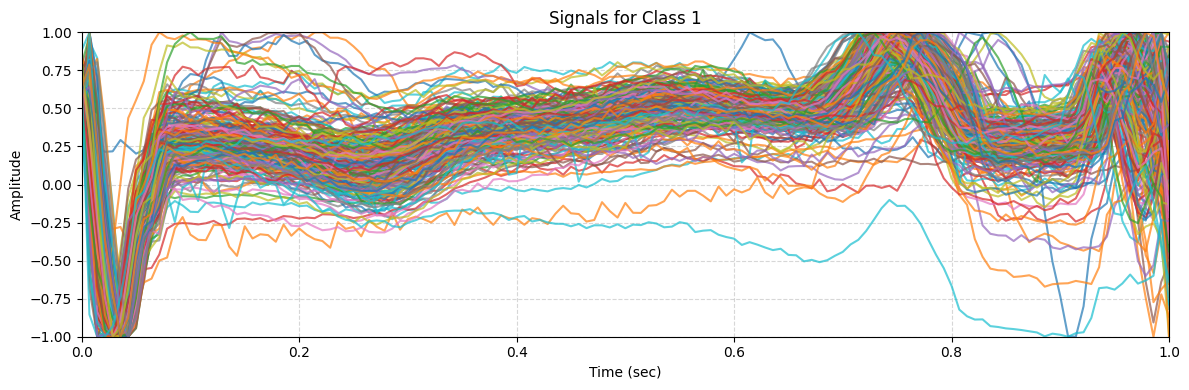

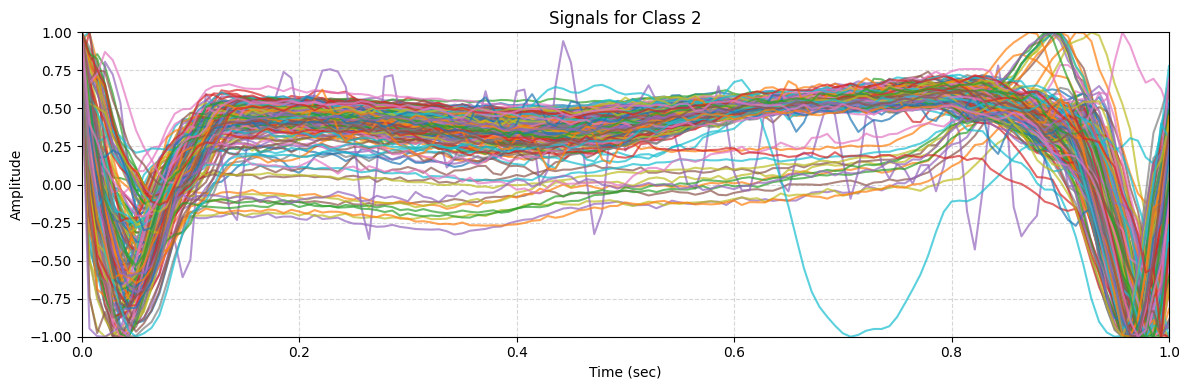

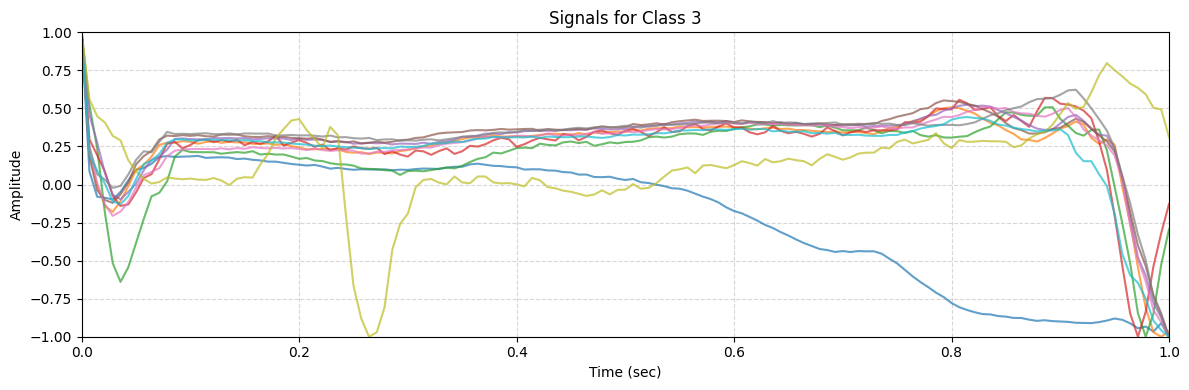

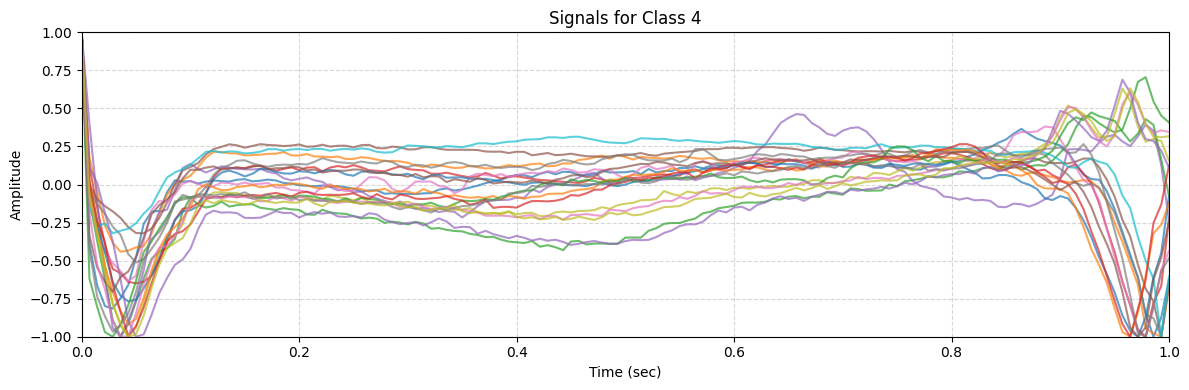

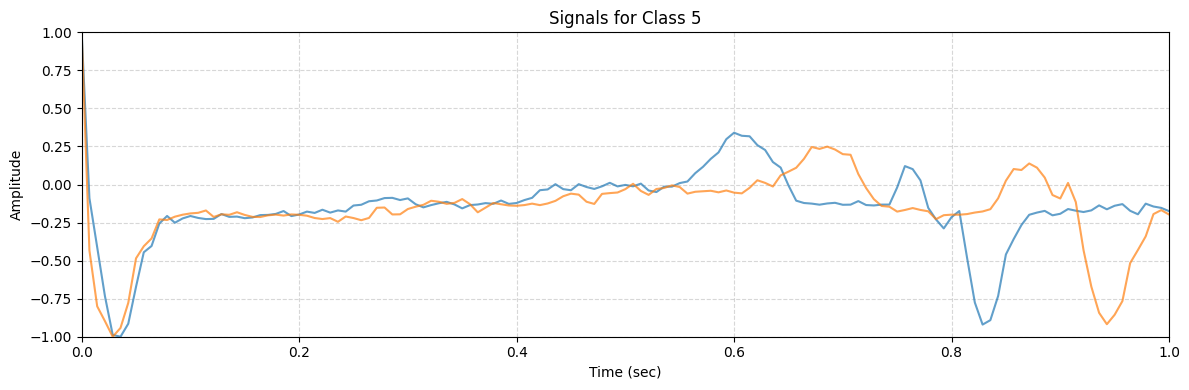

In [173]:
# Each class signals is represented in a seperate figure


# Time axis
time_axis = np.linspace(0, 1, df.shape[1]-1)

# Fixed: use plt.get_cmap instead of plt.cm.get_cmap
colormap = plt.get_cmap('tab20')

# ---------- 1. Global Signal Plot ----------
fig_global, ax_global = plt.subplots(figsize=(12, 4))
for i in range(len(df)):
    ax_global.plot(time_axis, df.iloc[i, :-1], color=colormap(i % 20), alpha=0.6)

ax_global.set_title("All Signals (Concatenated)")
ax_global.set_xlim([0, 1])
ax_global.set_ylim([-1, 1])
ax_global.set_xlabel("Time (sec)")
ax_global.set_ylabel("Amplitude")
ax_global.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------- 2. One Plot Per Class ----------
for idx, cls in enumerate(unique_classes):
    class_data = df[df["Class"] == cls].iloc[:, :-1]

    fig_class, ax_class = plt.subplots(figsize=(12, 4))
    class_cmap = plt.get_cmap('tab10')  # Up to 10 distinct colors per class

    for j in range(len(class_data)):
        ax_class.plot(time_axis, class_data.iloc[j, :], color=class_cmap(j % 10), alpha=0.7)

    ax_class.set_title(f'Signals for Class {cls}')
    ax_class.set_xlim([0, 1])
    ax_class.set_ylim([-1, 1])
    ax_class.set_xlabel("Time (sec)")
    ax_class.set_ylabel("Amplitude")
    ax_class.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


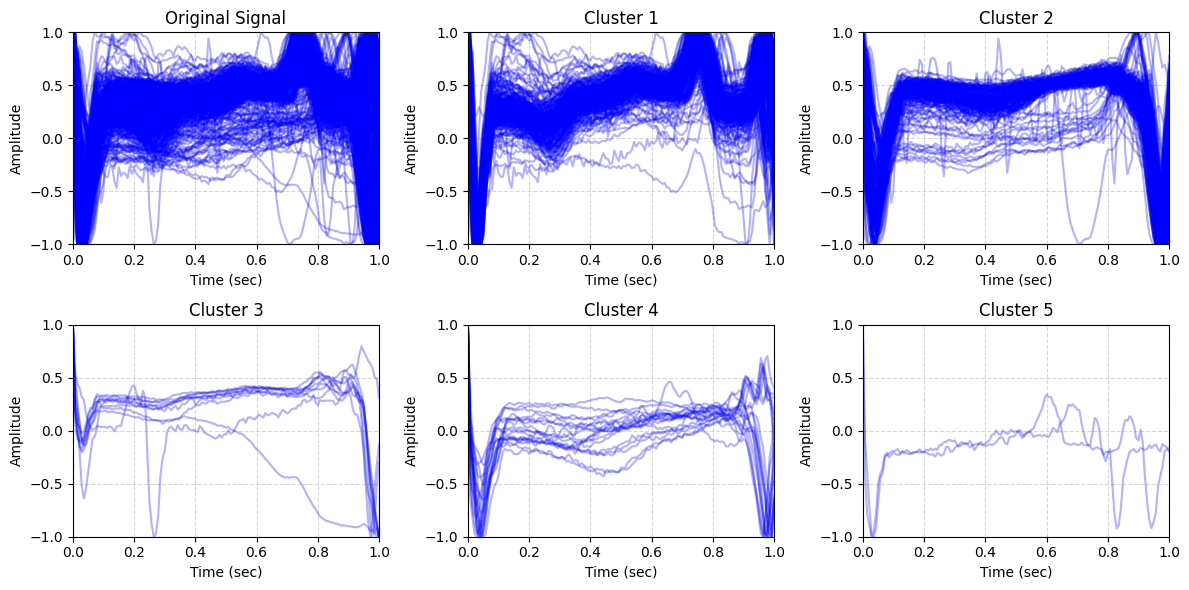

In [174]:
# All class signals in one plot

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for j in range(len(df)):
    axes[0].plot(time_axis, df.iloc[j, :-1], color='blue', alpha=0.3)
    
# Plot the hearbeats concatenated
axes[0].set_title("Original Signal")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([-1, 1])
axes[0].set_xlabel("Time (sec)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot the sub-sets of heartbeats (clusters) – one per class

for i, cls in enumerate(unique_classes):
    subset = df[df["Class"] == cls].iloc[:, :-1]
    for j in range(len(subset)):
        axes[i+1].plot(time_axis, subset.iloc[j, :], color='blue', alpha=0.3)
    axes[i+1].set_title(f'Cluster {cls}')
    axes[i+1].set_xlim([0, 1])
    axes[i+1].set_ylim([-1, 1])
    axes[i+1].set_xlabel("Time (sec)")
    axes[i+1].set_ylabel("Amplitude")
    axes[i+1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretation
The dataset contains significant variability across signals, with notable class imbalances. Class 1 comprises 292 distinct signals showing diverse amplitude and frequency characteristics, while Class 5 contains only 2 signals, representing the rarest pattern in the collection.


# 2.3
Use Fast Fourier Transform (FFT) for frequency analysis from MAT-
LAB [1] or Python [2, 3]. Plot time-domain signals, apply FFT, and

analyze both time-domain representations and frequency spectra of a

selected representative signal per heartbeat class using Python or MAT-
LAB.

## Answers
For each class, we select the first signal as the representative sample. We visualize it in both time domain (left subplot) and frequency domain (right subplot), using SciPy's FFT implementation to compute the Fast Fourier Transform. This side-by-side comparison reveals both temporal patterns and spectral characteristics.

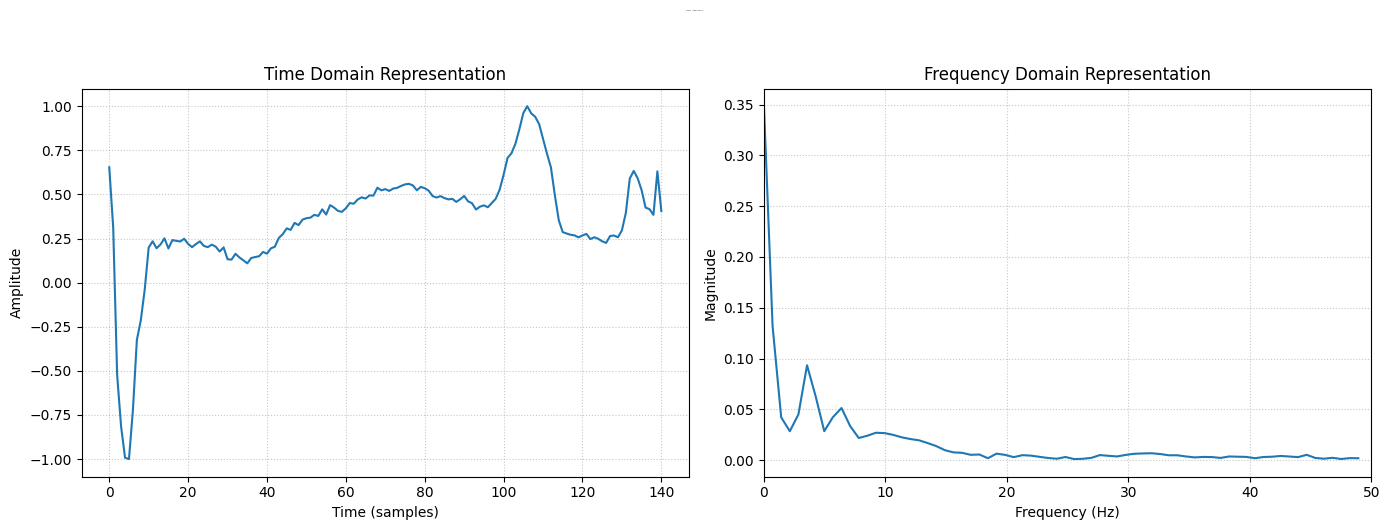

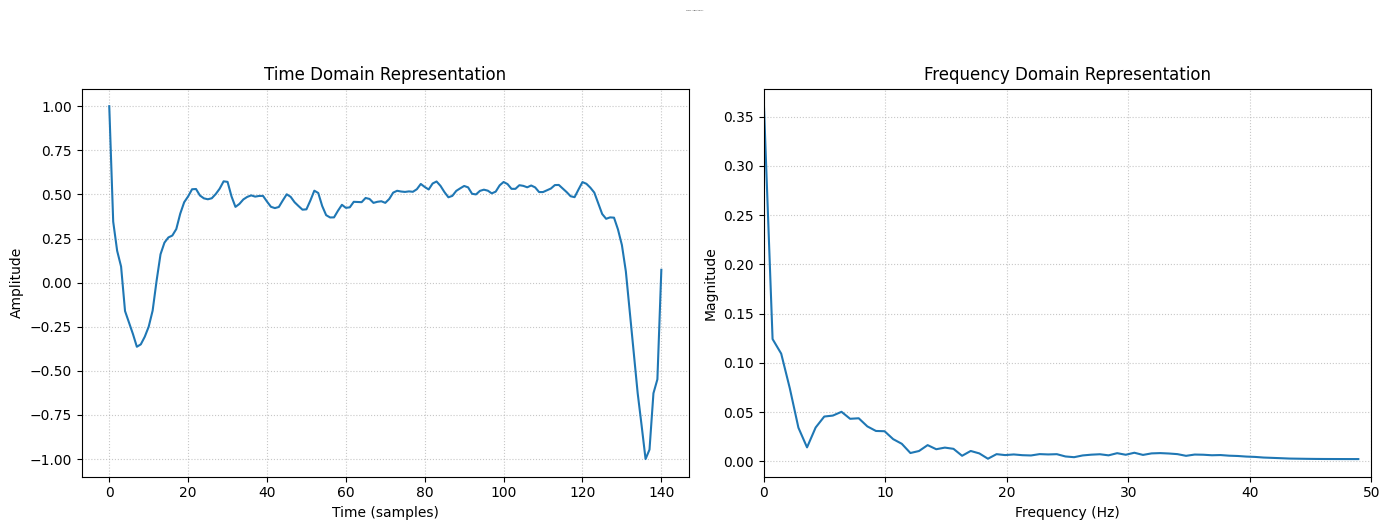

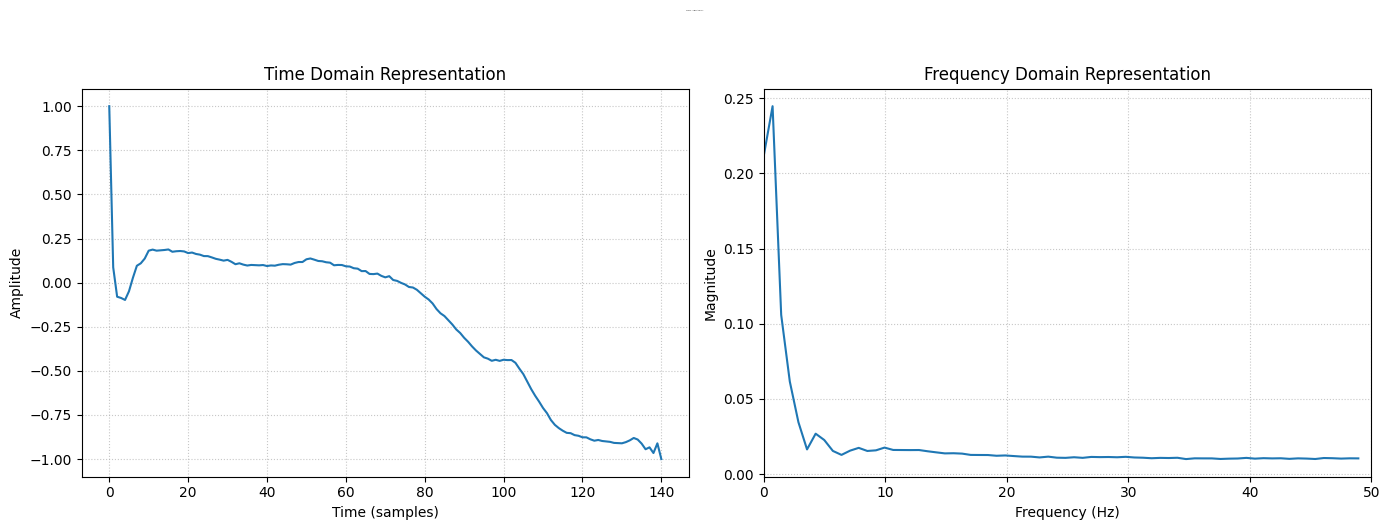

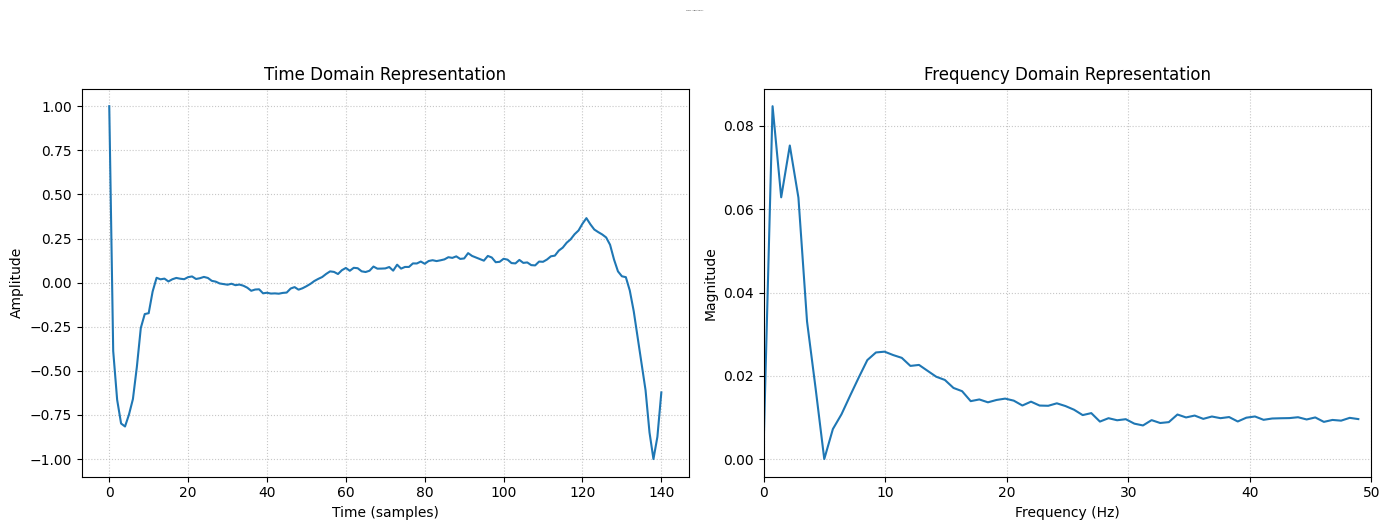

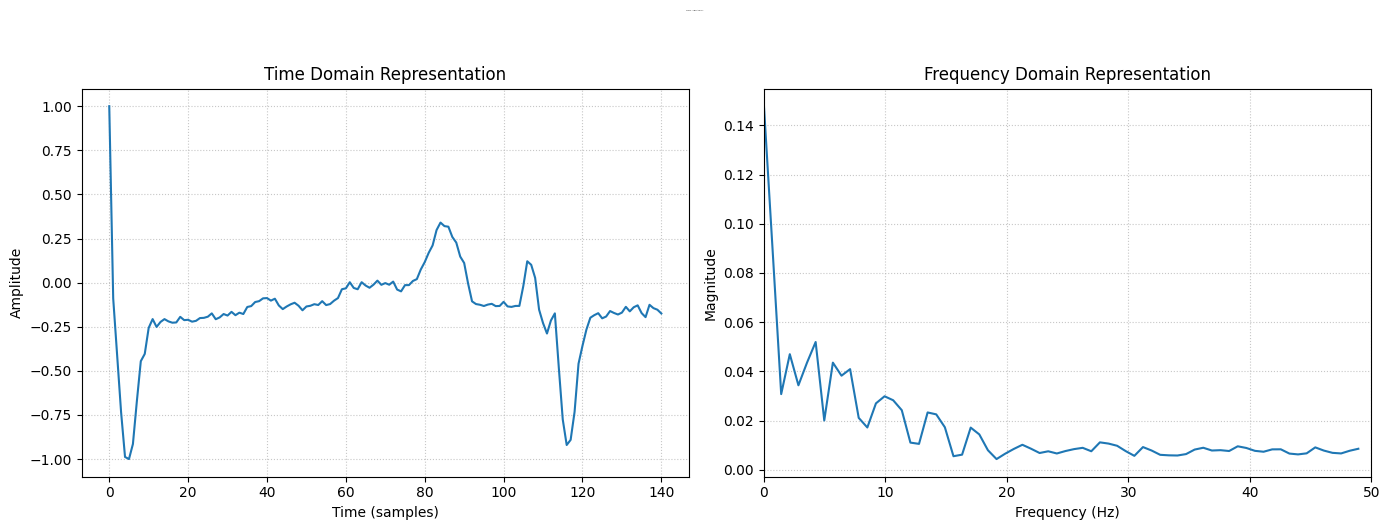

In [175]:

# Parameters
fs = 100  # Sampling frequency (Hz)
n_classes = len(df["Class"].unique())

# Process each class
for class_label, group in df.groupby("Class"):
    signals = group.drop("Class", axis=1).values
    representative_signal = signals[0]  # Use the first signal as representative

    # FFT computation
    fft_transformed = np.fft.fft(representative_signal)
    fft_magnitude = np.abs(fft_transformed)/len(representative_signal)
    freq = np.fft.fftfreq(len(representative_signal), d=1/fs)

    # Create figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Class {class_label} - Signal Analysis', fontsize=1, y=1.05)
    
    # --- Time domain Plot (Left) ---
    ax1.plot(representative_signal)
    ax1.set_title('Time Domain Representation')
    ax1.set_xlabel('Time (samples)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # --- Frequency domain Plot (Right) ---
    ax2.plot(freq[:len(freq)//2], fft_magnitude[:len(freq)//2])  # Plot only positive frequencies
    ax2.set_title('Frequency Domain Representation')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Magnitude')
    ax2.set_xlim(0, 50)  # Show up to Nyquist frequency (fs/2)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

## Interpretation
The data shows a clear inverse relationship between frequency and amplitude, with higher frequencies exhibiting lower amplitudes, consistent with biological signal characteristics. Each class displays distinct morphological patterns in both time and frequency domains, with normal rhythms showing concentrated low-frequency power (0.5-5 Hz) while abnormal cases exhibit broader spectral distributions. These pronounced differences in signal shapes and spectral profiles enable reliable class discrimination through either time-domain or frequency-domain analysis.


# 2.4
Plot and interpret PSD and spectrogram representations of a selected
representative signal per heartbeat class using Python or MATLAB.

## Answers
We compute the mean signal for each class, then generate two frequency-domain representations: (1) Power Spectral Density (PSD) using Welch's method (via scipy.signal.welch), plotted against frequency, and (2) a spectrogram via FFT, visualizing frequency content over time.

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 142, using nperseg = 142
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
C:\Users\USER\AppData\Local\Temp\ipykernel_16848\2936970845.py:25: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=142).
  plt.specgram(fft_transformed/71,Fs=140,cmap='jet_r')
C:\Users\USER\AppData\Local\Temp\ipykernel_16848\2936970845.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 2000x800 with 15 Axes> than <Figure size 1400x500 with 3 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax2)


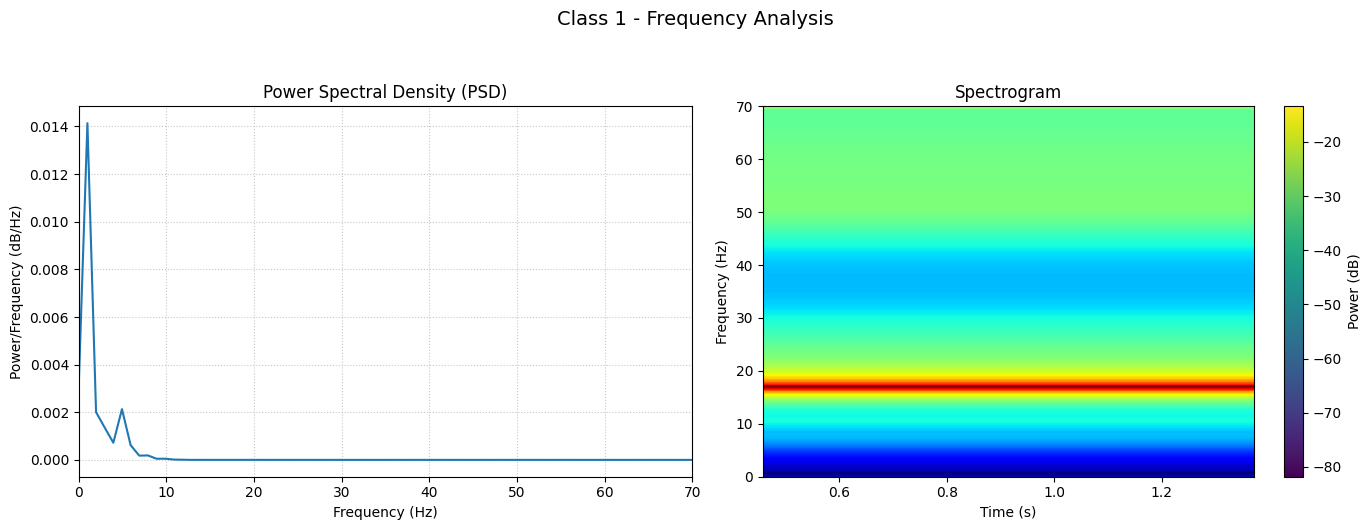

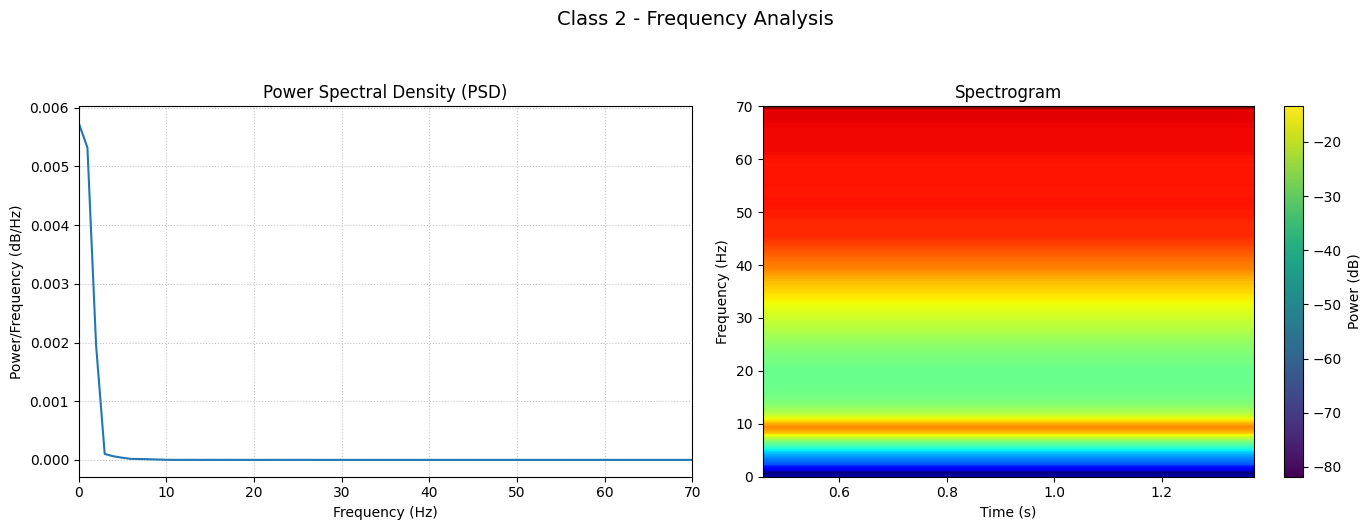

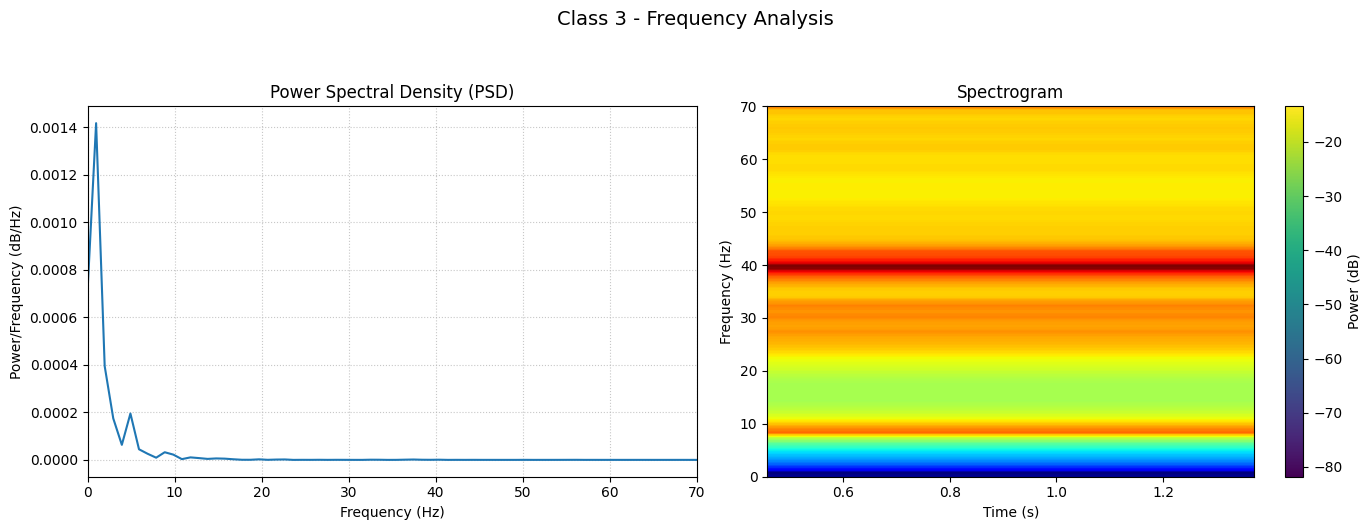

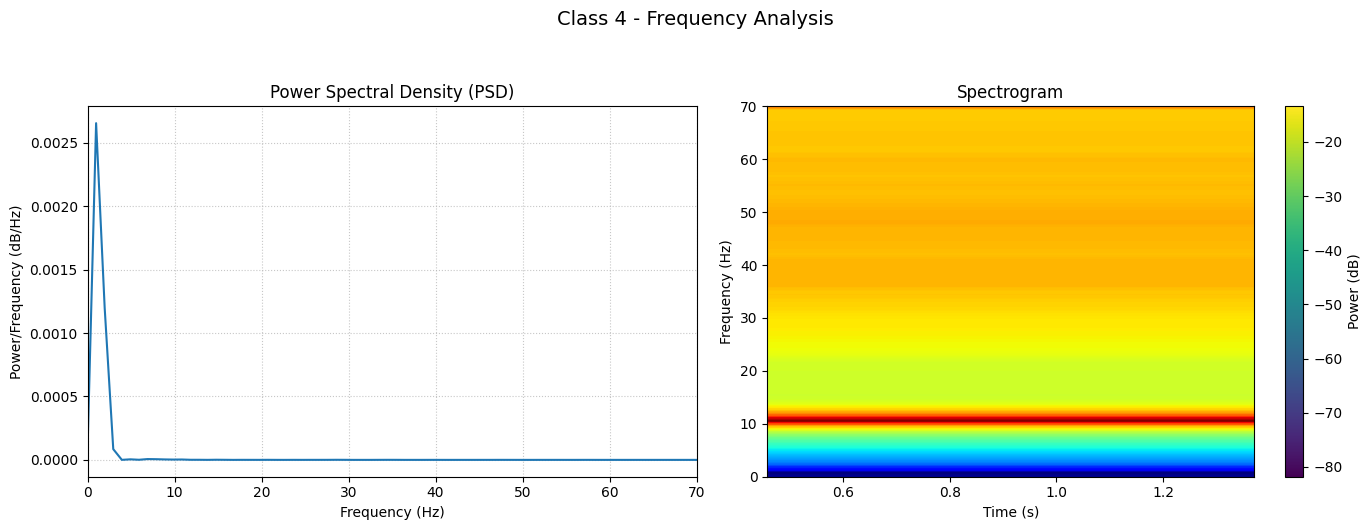

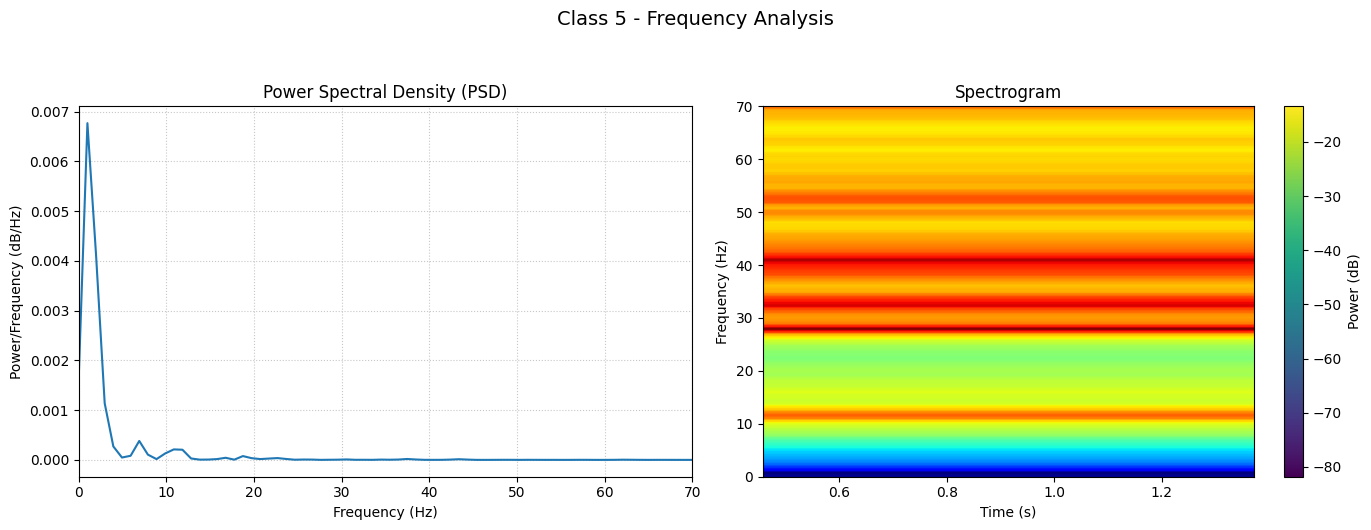

In [176]:
# Parameters
fs = 140  # Sampling frequency (Hz)
unique_classes = sorted(df["Class"].unique())

# Process each class
for class_label in unique_classes:
    # Get mean signal for the class
    mean_signal = df[df['Class'] == class_label].mean()

    # Create figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Class {class_label} - Frequency Analysis', fontsize=14, y=1.05)
    
    # --- PSD Plot (Left) ---
    f_psd, Pxx = welch(mean_signal, fs)
    ax1.plot(f_psd, Pxx)
    ax1.set_title('Power Spectral Density (PSD)')
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Power/Frequency (dB/Hz)')
    ax1.set_xlim(0, 70)  # Up to Nyquist frequency
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # --- Spectrogram Plot (Right) ---
    fft_transformed = np.abs(np.fft.fft(mean_signal))
    plt.specgram(fft_transformed/71,Fs=140,cmap='jet_r')
    ax2.set_title('Spectrogram')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_ylim(0, 70)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Power (dB)')
    
    plt.tight_layout()
    plt.show()

# Interpretation


The power spectral density (PSD) shows that most of the ECG signal's energy is concentrated in the 0 to 20 Hz range, with a strong peak around 1 to 2 Hz, which corresponds to a normal heartbeat frequency. Frequencies above 30 Hz are weak, which is expected for ECG signals. 

The spectrogram displays a clear and consistent heartbeat rhythm around 1 to 2 Hz, with some higher frequencies that diminish after 20 to 30 Hz. When analyzing by class, class 1 signals have a caracteristic frequency near 18 Hz, classes 2 and 4 show caracteristic frequency around 12 Hz, while classes 3 and 5 include more high-frequency components, often extending beyond 25 Hz.
